In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("Econ126_Discussion_Week_04.ipynb")

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'

# Discussion: Week 4

## Exercise: More Business Cycle Data

The file `business_cycle_dev_data_actual_trend.csv`, available at https://raw.githubusercontent.com/letsgoexploring/computational-macroeconomics/master/Data/Csv/business_cycle_data_actual_trend.csv, contains actual and trend data for real GDP per capita, real consumption per capita, real investment per capita, real physical capital per capita, TFP,  hours per capita, real M2 per capita, the rate of PCE (personal consumption expenditures) inflation, the three month T-bill rate, and the unemployment rate at quarterly frequency. The GDP, consumption, investment, capital, and M2 data are in terms of 2012 dollars. Hours is measured as an index with the value in October 2012 set to 100. PCE inflation is measured at the percent change from one year prior. PCE inflation, unemployment, and the T-bill rate are expressed in units of percent.

In this Notebook, you will replicate the work from class 9 but for the following quantities:
* Real GDP per capita
* 3-month T-Bill rate
* PCE inflation rate
* Unemployment rate

Refer to the Notebook from Class 9 for reference.

<!-- BEGIN QUESTION -->

## Part (a): Preliminaries

In [17]:
# Read 'business_cycle_dev_data_actual_trend.csv' into a Pandas DataFrame with the first column set as the index and `parse_dates=True`
# BEGIN SOLUTION
df = pd.read_csv('https://raw.githubusercontent.com/letsgoexploring/computational-macroeconomics/master/Data/Csv/business_cycle_data_actual_trend.csv',index_col=0,parse_dates=True)
# END SOLUTION

# Display the last five rows of the data
# BEGIN SOLUTION
df.tail()
# END SOLUTION

,gdp,gdp_trend,consumption,consumption_trend,investment,investment_trend,hours,hours_trend,capital,capital_trend,tfp,tfp_trend,real_m2,real_m2_trend,t_bill_3mo,t_bill_3mo_trend,pce_inflation,pce_inflation_trend,unemployment,unemployment_trend
date,,,,,,,,,,,,,,,,,,,,
2022-04-01,82.324442,82.246223,56.125677,55.764176,15.273074,14.836408,100.205187,98.688701,96.395301,96.333780,28.743500,29.008726,69.837306,68.395929,0.010767,0.022932,0.068100,0.047115,0.036000,0.045279
2022-07-01,82.712095,82.568594,56.269153,56.035244,15.033227,14.900029,100.618046,98.861809,96.933507,96.795776,28.745699,29.040603,68.822913,69.098116,0.026633,0.025123,0.065631,0.049830,0.035667,0.044176
2022-10-01,83.076396,82.891852,56.363988,56.307483,15.087918,14.962838,100.743085,99.039916,97.387061,97.259153,28.801913,29.071574,67.309262,69.785636,0.040400,0.027422,0.059042,0.052509,0.036000,0.043044
2023-01-01,83.092935,83.216072,56.615749,56.580915,14.644915,15.025212,100.843929,99.220438,97.505364,97.724182,28.776689,29.102131,65.281534,70.467455,0.046267,0.029790,0.050348,0.055160,0.035000,0.041896
2023-04-01,83.359726,83.541447,56.734387,56.855599,14.724291,15.087617,100.278046,99.401834,97.846271,98.191218,28.939499,29.132600,64.113826,71.151304,0.050733,0.032192,0.038650,0.057799,0.035667,0.040742


<!-- END QUESTION -->



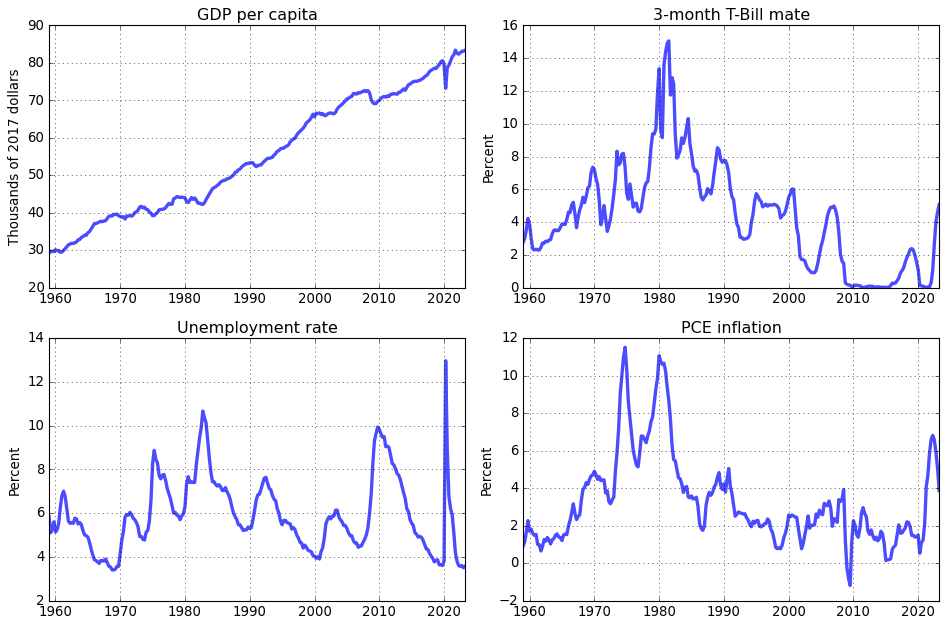

In [18]:
# Construct a 2x2 grid of plots of GDP, consumption, t_bill_3mo, unemployment, and pce_inflation. Multiply
# t_bill_3mo, unemployment, and pce_inflation by 100 inside the plot command to plot in units of percent.

# Load metadata for dataset and set base_year
pwt_metadata = pd.read_csv('https://raw.githubusercontent.com/letsgoexploring/computational-macroeconomics/master/Data/Csv/pwt_metadata.csv',index_col=0)['Values']
base_year = pwt_metadata['base_year']

# Plot data
fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(2,2,1)
ax1.plot(df.gdp,'-',lw=3,alpha = 0.7)
ax1.grid()
ax1.set_title('GDP per capita')
ax1.set_ylabel('Thousands of '+base_year+' dollars')

ax2 = fig.add_subplot(2,2,2)
ax2.plot(df.t_bill_3mo*100,'-',lw=3,alpha = 0.7)
ax2.grid()
ax2.set_title('3-month T-Bill mate')
ax2.set_ylabel('Percent')

ax3 = fig.add_subplot(2,2,3)
ax3.plot(df.unemployment*100,'-',lw=3,alpha = 0.7)
ax3.grid()
ax3.set_title('Unemployment rate')
ax3.set_ylabel('Percent')

ax4 = fig.add_subplot(2,2,4)
ax4.plot(df.pce_inflation*100,'-',lw=3,alpha = 0.7)
ax4.grid()
ax4.set_title('PCE inflation')
ax4.set_ylabel('Percent')

fig.tight_layout()

## Part (b): Cycles and Trends

Recall: A time series $X_t$ can be decomposed into a trend component $X_t^{trend}$ and a cyclical component $X_t^{cycle}$ such that:

\begin{align}
X_t & = X_t^{trend} + X_t^{cycle}. \tag{1}
\end{align}

In equation (1), $X_t^{trend}$ is the long-run value about which $X_t$ fluctuates. $X^{cycle}_t$ is the amount by which $X_t$ excedes its trend.

Often times, it's useful to express the cyclical component of a time series as the percent deviation of the series from trend (divided by 100):

\begin{align}
\hat{x}_t & = \frac{X_t-X_t^{trend}}{X_t^{trend}} = \frac{X_t^{cycle}}{X_t^{trend}}
\end{align} 

### GDP

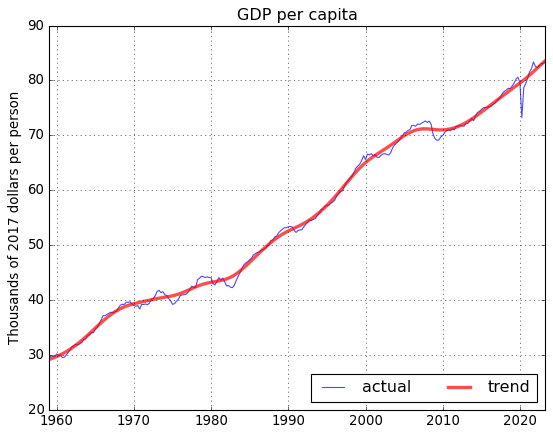

In [19]:
# Construct a plot of real GDP with its trend with:
#    1. Actual line: blue with lw=1, alpha=0.7, label = 'actual'
#    2. Trend line:  red with lw=3, alpha=0.7, label = 'trend'
#    3. A legend in an appropriate place
plt.plot(df.gdp,'-',lw=1,alpha = 0.7,label='actual')
plt.plot(df.gdp_trend,'r-',lw=3,alpha = 0.7,label='trend')
plt.grid()
plt.ylabel('Thousands of '+base_year+' dollars per person')
plt.title('GDP per capita')
plt.legend(loc='lower right',ncol=2);

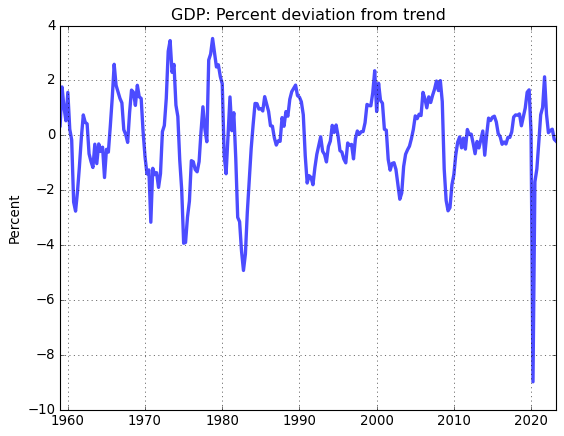

In [20]:
# Create a new column called gdp_cycle_dev equal to the percent deviation of actual 
# GDP relative to trend GDP (divided by 100):
df['gdp_cycle_dev'] = (df['gdp'] - df['gdp_trend'])/df['gdp']

# Plot the percent deviation of GDP from its trend
plt.plot(df.gdp_cycle_dev*100,'b-',lw=3,alpha = 0.7)
plt.ylabel('Percent')
plt.title('GDP: Percent deviation from trend')
plt.grid()

<!-- BEGIN QUESTION -->

### 3-month T-bill rate

When a data series is already in units of percent, it is common to just work with the difference between the actual data and trend (instead of the percent deviation of the series from trend). That is, 

\begin{align}
\hat{x}_t & = {X_t}-{X_t^{trend}}
\end{align} 

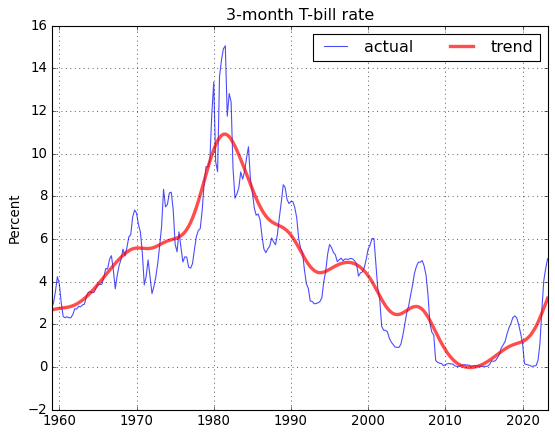

In [6]:
# Construct a plot of the 3-month T-bill rate (times 100) with its trend with:
#    1. Actual line: blue with lw=1, alpha=0.7, label = 'actual'
#    2. Trend line:  red with lw=3, alpha=0.7, label = 'trend'
#    3. A legend in an appropriate place
# BEGIN SOLUTION
plt.plot(df.t_bill_3mo*100,'-',lw=1,alpha = 0.7,label='actual')
plt.plot(df.t_bill_3mo_trend*100,'r-',lw=3,alpha = 0.7,label='trend')
plt.ylabel('Percent')
plt.title('3-month T-bill rate')
plt.legend(loc='upper right',ncol=2)
plt.grid()
# END SOLUTION

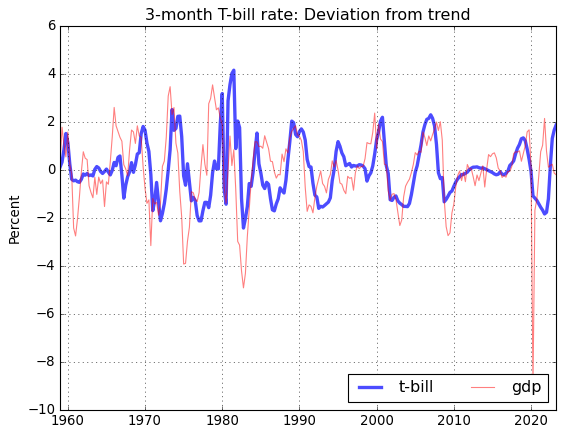

In [7]:
# Create a new column called 't_bill_3mo_cycle_dev' equal to the DIFFERENCE (not percent difference!) between actual 
# 3-month T-bill rate and it's trend:
# BEGIN SOLUTION
df['t_bill_3mo_cycle_dev'] = df['t_bill_3mo'] - df['t_bill_3mo_trend']
# END SOLUTION

# BEGIN SOLUTION
# Plot the deviation of the 3-month T-bill rate from its trend (times 100)
plt.plot(df.t_bill_3mo_cycle_dev*100,'b-',lw=3,alpha = 0.7,label='t-bill')
plt.plot(df.gdp_cycle_dev*100,'r-',lw=1,alpha = 0.5,label='gdp')
plt.ylabel('Percent')
plt.title('3-month T-bill rate: Deviation from trend')
plt.legend(loc='lower right',ncol=2)
plt.grid()
# END SOLUTION

### Unemployment rate

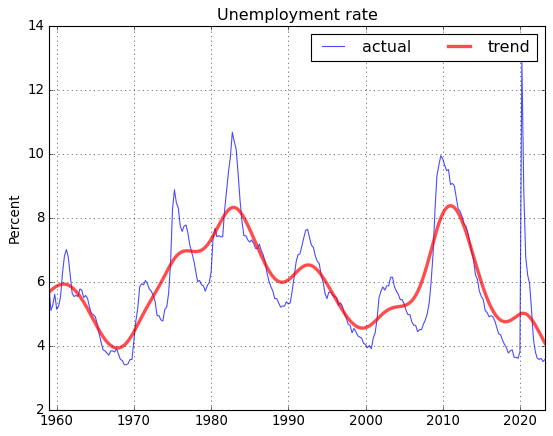

In [8]:
# Construct a plot of the unemployment rate (times 100) with its trend with:
#    1. Actual line: blue with lw=1, alpha=0.7, label = 'actual'
#    2. Trend line:  red with lw=3, alpha=0.7, label = 'trend'
#    3. A legend in an appropriate place
# BEGIN SOLUTION
plt.plot(df.unemployment*100,'-',lw=1,alpha = 0.7,label='actual')
plt.plot(df.unemployment_trend*100,'r-',lw=3,alpha = 0.7,label='trend')
plt.ylabel('Percent')
plt.title('Unemployment rate')
plt.legend(loc='upper right',ncol=2)
plt.grid()
# END SOLUTION

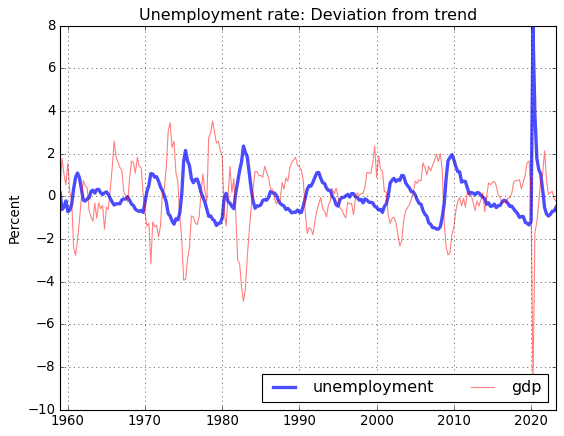

In [9]:
# Create a new column called 'unemployment_cycle_dev' equal to the DIFFERENCE (not percent difference!) between actual 
# unemployment and it's trend:
# BEGIN SOLUTION
df['unemployment_cycle_dev'] = df['unemployment'] - df['unemployment_trend']
# END SOLUTION

# Plot the deviation of the unemployment rate from its trend (times 100)
# BEGIN SOLUTION
plt.plot(df.unemployment_cycle_dev*100,'b-',lw=3,alpha = 0.7,label='unemployment')
plt.plot(df.gdp_cycle_dev*100,'r-',lw=1,alpha = 0.5,label='gdp')
plt.ylabel('Percent')
plt.title('Unemployment rate: Deviation from trend')
plt.legend(loc='lower right',ncol=2)
plt.grid()
# END SOLUTION

### PCE Inflation

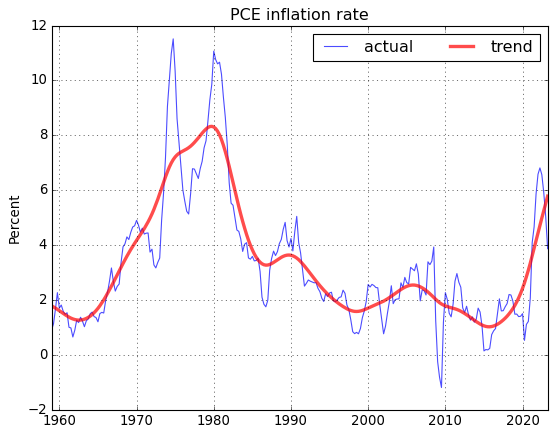

In [10]:
# Construct a plot of the pce_inflation rate (times 100) with its trend with:
#    1. Actual line: blue with lw=1, alpha=0.7, label = 'actual'
#    2. Trend line:  red with lw=3, alpha=0.7, label = 'trend'
#    3. A legend in an appropriate place
# BEGIN SOLUTION
plt.plot(df.pce_inflation*100,'-',lw=1,alpha = 0.7,label='actual')
plt.plot(df.pce_inflation_trend*100,'r-',lw=3,alpha = 0.7,label='trend')
plt.ylabel('Percent')
plt.title('PCE inflation rate')
plt.legend(loc='upper right',ncol=2)
plt.grid()
# END SOLUTION

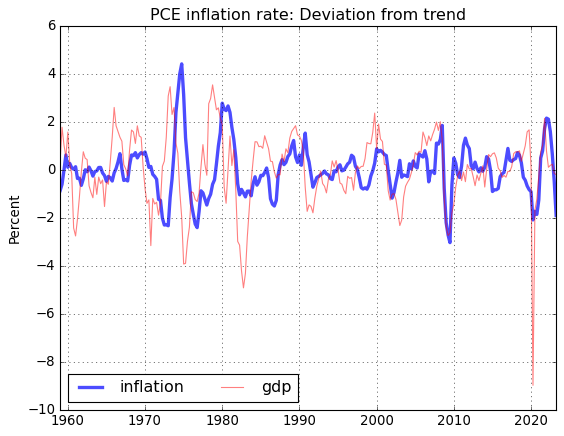

In [11]:
# Create a new column called 'pce_inflation_cycle_dev equal' to the DIFFERENCE (not percent difference!) between actual 
# pce_inflation and it's trend:
# BEGIN SOLUTION
df['pce_inflation_cycle_dev'] = df['pce_inflation'] - df['pce_inflation_trend']
# END SOLUTION

# Plot the deviation of the PCE inflation rate from its trend (times 100)
# BEGIN SOLUTION
plt.plot(df.pce_inflation_cycle_dev*100,'b-',lw=3,alpha = 0.7,label='inflation')
plt.plot(df.gdp_cycle_dev*100,'r-',lw=1,alpha = 0.5,label='gdp')
plt.ylabel('Percent')
plt.title('PCE inflation rate: Deviation from trend')
plt.legend(loc='lower left',ncol=2)
plt.grid()
# END SOLUTION

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Part (c): Statistics

In [12]:
# Create a new variable called df_cycle_dev that is a DataFrame with columns columns gdp_cycle_dev, t_bill_3mo_cycle_dev, 
# pce_inflation_cycle_dev, unemployment_cycle_dev from df.
# BEGIN SOLUTION
df_cycle_dev = df[['gdp_cycle_dev', 't_bill_3mo_cycle_dev', 'pce_inflation_cycle_dev', 'unemployment_cycle_dev']]
# END SOLUTION

# Print the first five rows of df_cycle_dev
# BEGIN SOLUTION
print(df_cycle_dev.head())
# END SOLUTION

            gdp_cycle_dev  t_bill_3mo_cycle_dev  pce_inflation_cycle_dev  \
date                                                                       
1959-01-01       0.003469              0.001081                -0.008789   
1959-04-01       0.017623              0.003105                -0.006146   
1959-07-01       0.010319              0.008295                -0.000346   
1959-10-01       0.005275              0.015022                 0.006096   
1960-01-01       0.015617              0.011318                 0.000958   

            unemployment_cycle_dev  
date                                
1959-01-01                0.001707  
1959-04-01               -0.006223  
1959-07-01               -0.005078  
1959-10-01               -0.002192  
1960-01-01               -0.007232  


In [13]:
# Use the DataFrame method .mean() to find to create a variable called `means` that contains the averages of the columns
#    of df_cycle_dev
# BEGIN SOLUTION
means = df_cycle_dev.mean()
# END SOLUTION

# Display the value of `means`
# BEGIN SOLUTION
display(means)
# END SOLUTION

gdp_cycle_dev             -0.000075
t_bill_3mo_cycle_dev      -0.000032
pce_inflation_cycle_dev   -0.000099
unemployment_cycle_dev    -0.000025
dtype: float64

In [14]:
# Use the DataFrame method .std() to find to create a variable called `standard_deviations` that contains the standard deviations
#    of the columns of df_cycle_dev
# BEGIN SOLUTION
standard_deviations = df_cycle_dev.std()
# END SOLUTION

# Display the value of `standard_deviations`
# BEGIN SOLUTION
display(standard_deviations)
# END SOLUTION

gdp_cycle_dev              0.015147
t_bill_3mo_cycle_dev       0.011791
pce_inflation_cycle_dev    0.010433
unemployment_cycle_dev     0.009386
dtype: float64

In [15]:
# Use the DataFrame method .corr() to find to create a variable called `correlations` that contains the correlations
#    among the columns of df_cycle_dev
# BEGIN SOLUTION
correlations = df_cycle_dev.corr()
# END SOLUTION

# Display the value of `correlations`
# BEGIN SOLUTION
display(correlations)
# END SOLUTION

,gdp_cycle_dev,t_bill_3mo_cycle_dev,pce_inflation_cycle_dev,unemployment_cycle_dev
gdp_cycle_dev,1.000000,0.376085,0.189259,-0.828086
t_bill_3mo_cycle_dev,0.376085,1.000000,0.481815,-0.497012
pce_inflation_cycle_dev,0.189259,0.481815,1.000000,-0.340257
unemployment_cycle_dev,-0.828086,-0.497012,-0.340257,1.000000


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Questions**

1. Of the three quantities besides GDP in the columns of `df_cycle_dev`, which varies the most over the business cycle?
2. Of the three quantities besides GDP in the columns of `df_cycle_dev`, which varies the least over the business cycle?
3. Of the three quantities besides GDP in the columns of `df_cycle_dev`, which is most correlated (in absolute value) with GDP over the business cycle?

_Type your answer here, replacing this text._

**Answers**

1. The PCE inflation rate fluctuates the most over the business cycle.<!-- answer -->
2. The unemployment rate fluctuates the least over the business cycle.<!-- answer -->
3. The unemployment rate is the quantity that is most correlated with GDP over the cycle. Since the capital stock changes slowly over time, large fluctuations due primarily to large fluctuations in employment.<!-- answer -->

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Part (d): Bonus

Do the next cell for fun. You won't get extra credit, but do it if you want to and have time.

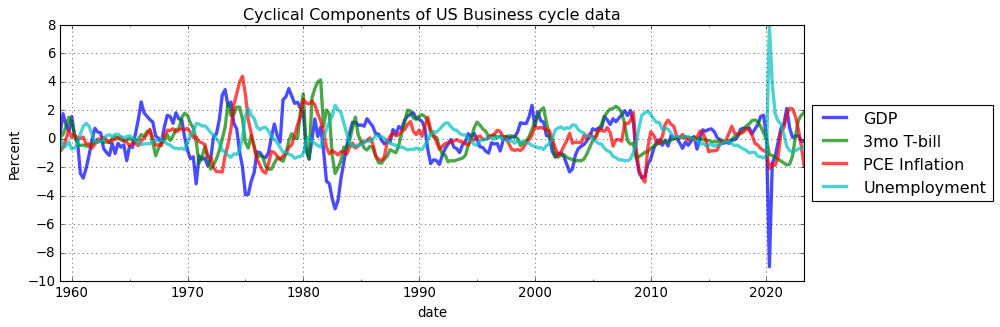

In [16]:
# Plot the cyclical components of GDP, three month T-bill rate, PCE inflation rate, and the unemployment rate
# (all times 100) on the same set of axes
# BEGIN SOLUTION
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,1,1)
(df_cycle_dev*100).plot(ax = ax,legend=False,lw=3,alpha=0.7)
ax.legend(['GDP','3mo T-bill','PCE Inflation','Unemployment'],loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('Percent')
ax.set_title('Cyclical Components of US Business cycle data')
ax.grid()
# END SOLUTION

<!-- END QUESTION -->

